### Chukchi Sea Bivalve question when are they being seen
Looking at samples from bivalve spawning event to see if the large cells are dropping out earlier

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


## Some chat to scrape the data and get just the images identified as bivalve larvae 

from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
roi_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/tag_class_roi_table_shellfishlarvae.csv")        # CSV with column: roi
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")     # directory containing *_adc_only.csv files
output_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv")

roi_col = "roi"
target_celltag_col = "taglabel" 
roi_number_col = "RoiNumber"

# -----------------------------
# Load target ROIs
# -----------------------------
targets = pd.read_csv(roi_csv)

# Split ROI string into sample ID and ROI number
# Example: D20230727T033456_IFCB145_00036
targets["sample_id"] = targets[roi_col].str.rsplit("_", n=1).str[0]
targets["roi_number"] = targets[roi_col].str.rsplit("_", n=1).str[1].astype(int)

# Keep original search string as metadata
targets["original_search_criteria"] = targets[roi_col]
targets["taglabel"] = targets[target_celltag_col]

# -----------------------------
# Match ROIs across ADC files
# -----------------------------
matched_rows = []

for adc_file in data_dir.glob("*_adc_only.csv"):
    # Example filename:
    # D20230727T030526_IFCB145_adc_only.csv
    sample_id = adc_file.name.replace("_adc_only.csv", "")

    # Check whether this file contains any target ROIs
    file_targets = targets[targets["sample_id"] == sample_id]

    if file_targets.empty:
        continue

    df = pd.read_csv(adc_file)

    # Make sure RoiNumber is numeric
    df[roi_number_col] = df[roi_number_col].astype(int)

    # Merge to retain only matching ROI rows
    matched = df.merge(
        file_targets[["roi_number", "original_search_criteria", target_celltag_col]],
        left_on=roi_number_col,
        right_on="roi_number",
        how="inner"
    )

    # Add useful metadata
    matched["source_file"] = adc_file.name
    matched["sample_id"] = sample_id
    matched = matched.rename(columns={target_celltag_col: "taglabel"})

    # Drop helper column if desired
    matched = matched.drop(columns=["roi_number"])

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows")
print(f"Saved to {output_csv}")

Matched 308 rows
Saved to /Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv


In [53]:
df = pd.read_csv(Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv"))


In [4]:
df.head(n=20)


,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,RoiWidth,RoiX,RoiY,original_search_criteria,taglabel,source_file,sample_id
0,19,19,-0.004840,30.460505,30.486986,1.493008,0.082977,0.120808,1,332,392,716,6,D20230727T070822_IFCB145_00019,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
1,42,42,-0.004473,49.729277,49.759818,3.404787,0.083843,0.193146,1,284,360,684,0,D20230727T070822_IFCB145_00042,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
2,62,62,0.000103,60.047546,60.078264,5.060339,0.082587,0.229241,1,164,424,676,0,D20230727T070822_IFCB145_00062,large1,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
3,62,62,0.000103,60.047546,60.078264,5.060339,0.082587,0.229241,1,164,424,676,0,D20230727T070822_IFCB145_00062,3cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
4,327,331,-0.003964,236.414763,236.450729,27.000358,0.082908,0.872710,1,276,304,740,390,D20230727T070822_IFCB145_00331,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
5,350,354,-0.004095,248.980601,249.016927,28.908166,0.082799,0.917120,1,308,320,732,270,D20230727T070822_IFCB145_00354,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
6,445,452,-0.004449,297.937030,297.974201,36.773945,0.082669,1.088334,1,340,336,716,222,D20230727T070822_IFCB145_00452,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
7,494,502,-0.004164,324.805422,324.845035,40.905182,0.083620,1.183083,1,284,336,748,342,D20230727T070822_IFCB145_00502,2cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
8,521,531,-0.004559,335.825470,335.864549,43.148819,0.082439,1.219649,1,276,376,684,174,D20230727T070822_IFCB145_00531,4cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
9,849,861,-0.003895,559.510302,559.569896,70.324822,0.082678,2.038521,1,340,392,708,278,D20230727T070822_IFCB145_00861,3cell,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145


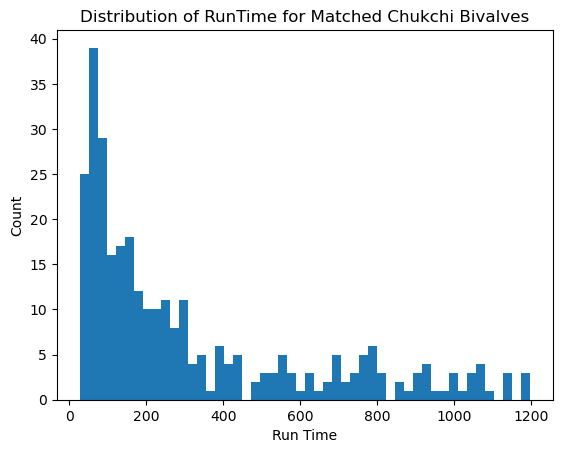

In [54]:
times = df["RunTime"].values
plt.hist(times, bins=50)
plt.xlabel("Run Time")
plt.ylabel("Count")
plt.title("Distribution of RunTime for Matched Chukchi Bivalves")
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chuck_bivalve_runtime_histogram.png")
plt.show()


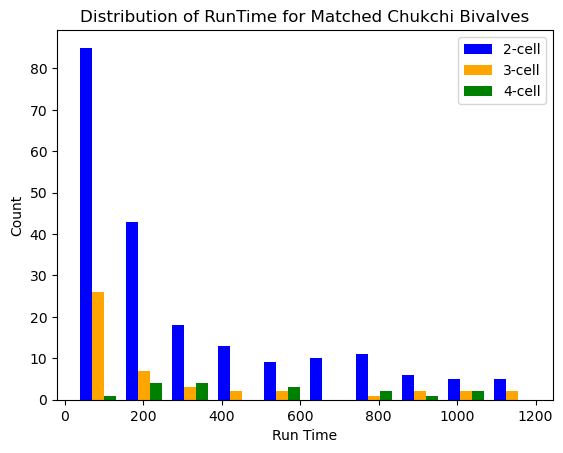

In [34]:
df2cell = df[df["taglabel"] == "2cell"]
df3cell = df[df["taglabel"] == "3cell"]
df4cell = df[df["taglabel"] == "4cell"]

plt.hist([df2cell["RunTime"], df3cell["RunTime"], df4cell["RunTime"]], label=["2-cell", "3-cell", "4-cell"], color=["blue", "orange", "green"])
plt.xlabel("Run Time")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of RunTime for Matched Chukchi Bivalves")
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chuck_bivalve_runtime_byclass_histogram.png")
plt.show()

## A Kolmogorov–Smirnov (KS) test to see if this is close enough to a uniform distribution and if that really makes sense
this test compares the observed data to a null model of a cumulative distribtuion function and with the assumption that if it is uniformly distributed than F(x) = x such that if you are 50% through your x you should be 50% throuhgh you y or in our case at time 600s we have seen 1/2 of our rois 


the ks stat tells us the largest difference between the null and observed CDF so ks = 0.43 means at some point the observed data diverges from the null by 43% in our case we can visually see that is 

In [35]:

from scipy.stats import kstest
import numpy as np

a = np.min(times)
b = np.max(times)

stat, p = kstest(times, 'uniform', args=(a, b-a))

print(f"K-S statistic: {stat}, p-value: {p}")

K-S statistic: 0.435509926193852, p-value: 1.1973444602480237e-53


KS statistic: 0.435509926193852
p-value: 1.1973444602480237e-53


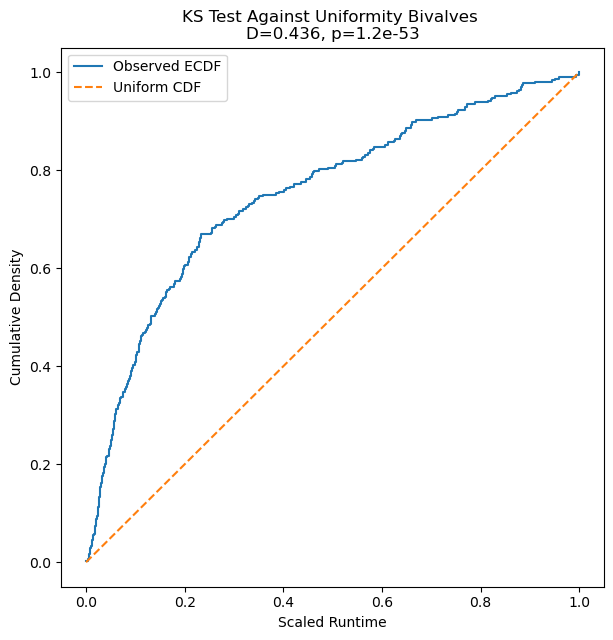

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(times)

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Bivalves \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_Bivalves.png", dpi=300)

plt.show()

## Background roi distribution


Loaded D20230727T070822_IFCB145_adc_only.csv: 1725 values
Loaded D20230727T081931_IFCB145_adc_only.csv: 1735 values
Loaded D20230727T062057_IFCB145_adc_only.csv: 1883 values
Loaded D20230727T084313_IFCB145_adc_only.csv: 1723 values
Loaded D20230727T125208_IFCB145_adc_only.csv: 6107 values
Loaded D20230727T030526_IFCB145_adc_only.csv: 2613 values
Loaded D20230727T035839_IFCB145_adc_only.csv: 2362 values
Loaded D20230727T122822_IFCB145_adc_only.csv: 6295 values
Loaded D20230727T055714_IFCB145_adc_only.csv: 2060 values
Loaded D20230727T044604_IFCB145_adc_only.csv: 2418 values
Loaded D20230727T120437_IFCB145_adc_only.csv: 6206 values
Loaded D20230727T042222_IFCB145_adc_only.csv: 2324 values
Loaded D20230727T102942_IFCB145_adc_only.csv: 8351 values
Loaded D20230727T033456_IFCB145_adc_only.csv: 2994 values
Loaded D20230727T105327_IFCB145_adc_only.csv: 3886 values
Loaded D20230727T100558_IFCB145_adc_only.csv: 5413 values
Loaded D20230727T090655_IFCB145_adc_only.csv: 1660 values
Loaded D202307

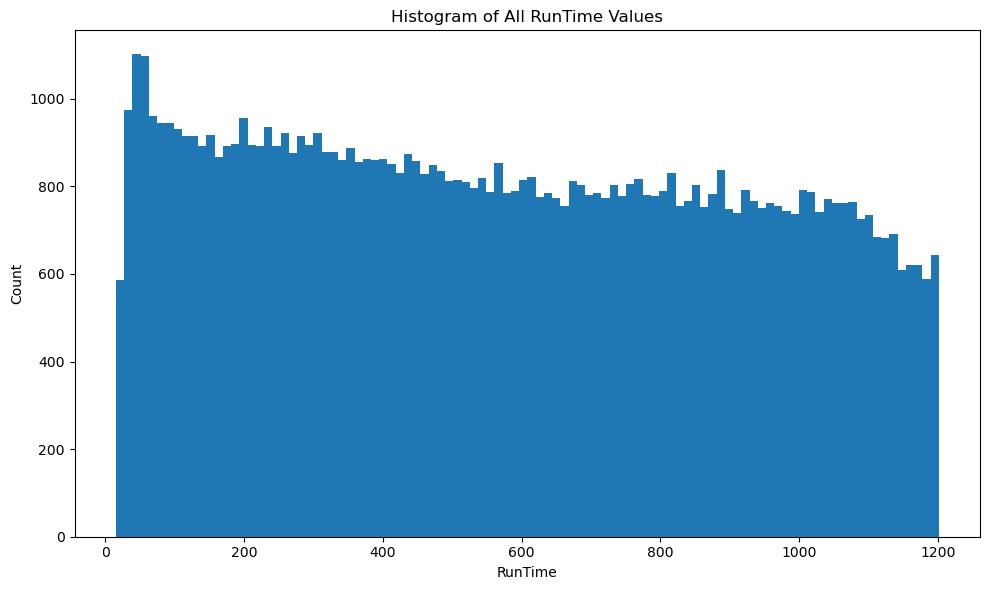

In [27]:

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")

runtime_col = "RunTime"
file_pattern = "*adc_only.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(runtime_series, bins=100)

plt.xlabel("RunTime")
plt.ylabel("Count")
plt.title("Histogram of All RunTime Values")

plt.tight_layout()
#plt.savefig("../Figs/chukchi/AllRunTimesHist.png")
plt.show()

## A Kolmogorov–Smirnov (KS) test to see if this is close enough to a uniform distribution and if that really makes sense
this test compares the observed data to a null model of a cumulative distribtuion function and with the assumption that if it is uniformly distributed than F(x) = x such that if you are 50% through your x you should be 50% throuhgh you y or in our case at time 600s we have seen 1/2 of our rois 


In [31]:

from scipy.stats import kstest
import numpy as np

a = np.min(runtime_series)
b = np.max(runtime_series)

stat, p = kstest(runtime_series, 'uniform', args=(a, b-a))

print(f"K-S statistic: {stat}, p-value: {p}")


K-S statistic: 0.0390990939443262, p-value: 8.488374843212661e-109


KS statistic: 0.0390990939443262
p-value: 8.488374843212661e-109


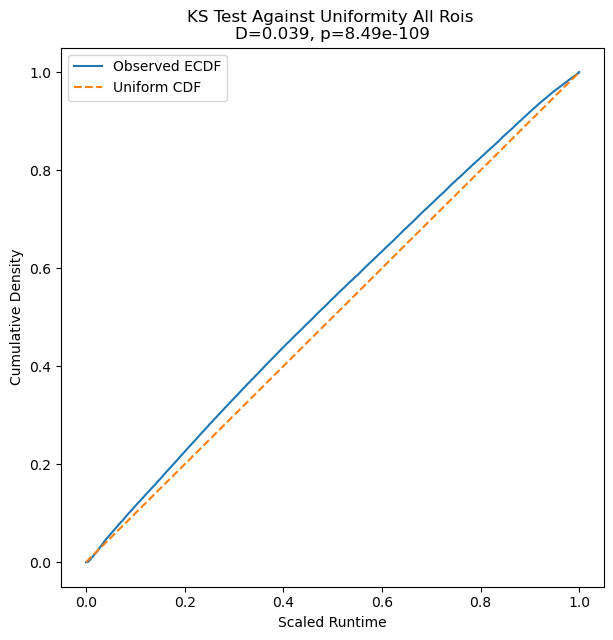

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(runtime_series)

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity All Rois \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_all.png", dpi=300)

plt.show()

### What if there was an out group do they seam to settle if it is a smaller cell
crytpoperidinium poorly classified but will work for this analysis as just sort of random small cell if we do the same analysis do they drop off after an initial burst

Reusing some code from TriposAnalysis to get just cryptoperidnium images

In [ ]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")
output_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/cryptoperidinium_master.csv")

score_col = "Kryptoperidinium_triquetrum"
alpha = 0.5 ## Using a relatively low threshold becuase we are bad at classifying these and dont really care just want small cells

# Optional: change this pattern if needed
file_pattern = "*keepzero.csv" ## using merged with class file csvs

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] > alpha].copy()

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} > {alpha}")
print(f"Saved to {output_csv}")

Matched 142 rows with Kryptoperidinium_triquetrum > 0.5
Saved to /Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/cryptoperidinium_master.csv


: 

In [44]:
df = pd.read_csv(Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/cryptoperidinium_master.csv"))
df.head()


,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,...,detritus_transparent,fecal_pellet,fiber,flagellate,flagellate_morphotype1,flagellate_morphotype3,pennate,unknown2,source_file,source_path
0,152,154,0.056171,42.657166,42.676753,12.512387,0.083945,0.125685,1,84,...,2.000000e-07,0.000000e+00,0.000000,0.000657,0.000161,1.000000e-07,2.000000e-07,0.0,D20230727T114053_IFCB145_merged_keepzero.csv,/Users/michaelstaiger/Desktop/gitRepos/IFCBPar...
1,321,326,-0.002235,64.359938,64.377409,26.508741,0.082088,0.157786,1,76,...,6.970000e-05,1.000000e-07,0.000009,0.002522,0.000013,6.000000e-08,1.253000e-04,0.0,D20230727T114053_IFCB145_merged_keepzero.csv,/Users/michaelstaiger/Desktop/gitRepos/IFCBPar...
2,357,364,0.075426,70.608757,70.626450,30.242376,0.082817,0.168267,1,92,...,9.500000e-07,3.000000e-07,0.000000,0.000434,0.002321,0.000000e+00,4.000000e-07,0.0,D20230727T114053_IFCB145_merged_keepzero.csv,/Users/michaelstaiger/Desktop/gitRepos/IFCBPar...
3,595,615,0.326269,106.225969,106.241363,49.938507,0.000000,0.234595,2,100,...,2.400000e-07,6.000000e-08,0.000000,0.000025,0.000122,0.000000e+00,8.300000e-07,0.0,D20230727T114053_IFCB145_merged_keepzero.csv,/Users/michaelstaiger/Desktop/gitRepos/IFCBPar...
4,957,984,0.070816,160.252828,160.265781,79.960017,0.082153,0.334607,1,92,...,2.563000e-05,4.500000e-06,0.000000,0.000013,0.000038,0.000000e+00,5.000000e-07,0.0,D20230727T114053_IFCB145_merged_keepzero.csv,/Users/michaelstaiger/Desktop/gitRepos/IFCBPar...


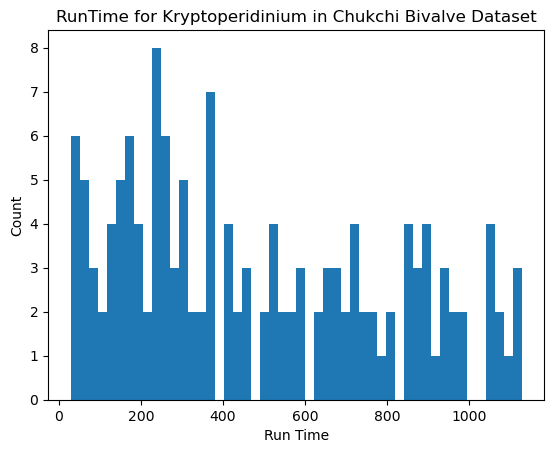

In [ ]:
times = df["RunTime"].values
plt.hist(times, bins=50)
plt.xlabel("Run Time")
plt.ylabel("Count")
plt.title("RunTime for Kryptoperidinium in Chukchi Bivalve Dataset")
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chuckchi_krypto_runtime_histogram.png", dpi=300)
plt.show()

KS statistic: 0.1775745088598658
p-value: 0.0002179669799695258


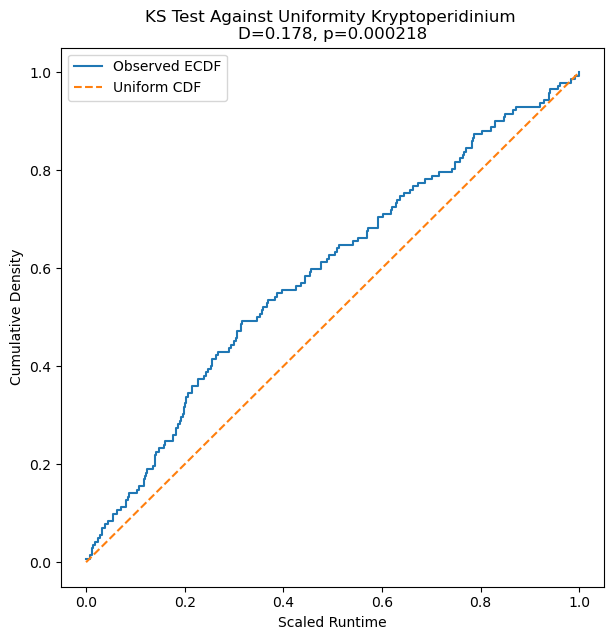

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(times)

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Kryptoperidinium \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_krypto.png", dpi=300)

plt.show()